(426728, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426728 entries, 0 to 426727
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           426728 non-null  int64  
 1   date         426728 non-null  object 
 2   store_nbr    426728 non-null  int64  
 3   family       426728 non-null  object 
 4   sales        426728 non-null  float64
 5   onpromotion  426728 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 19.5+ MB
None
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


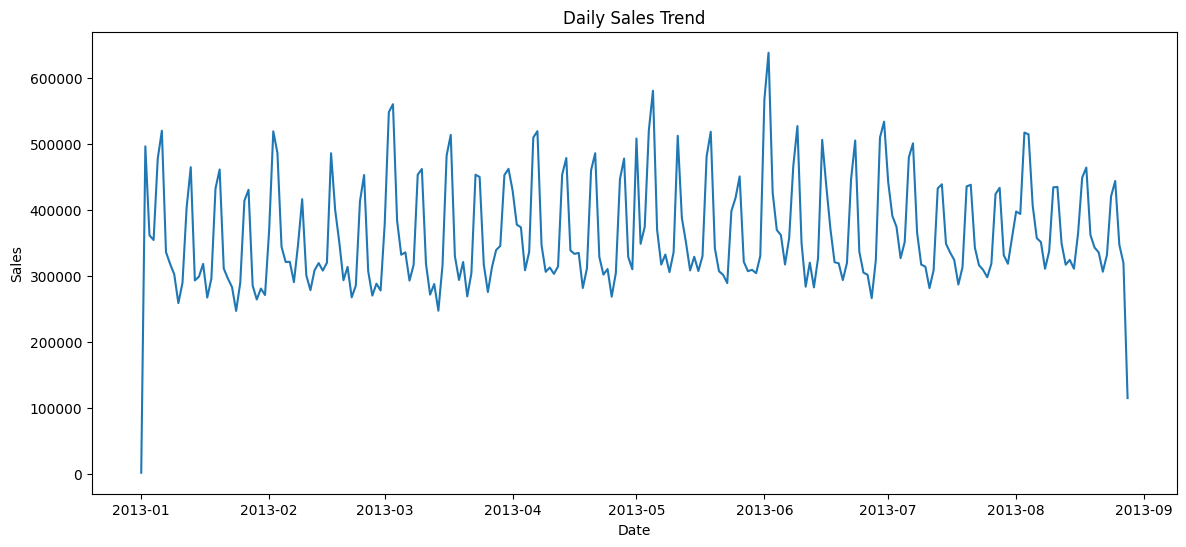

MAE = 62766.82963475127
RMSE = 75304.48351526674


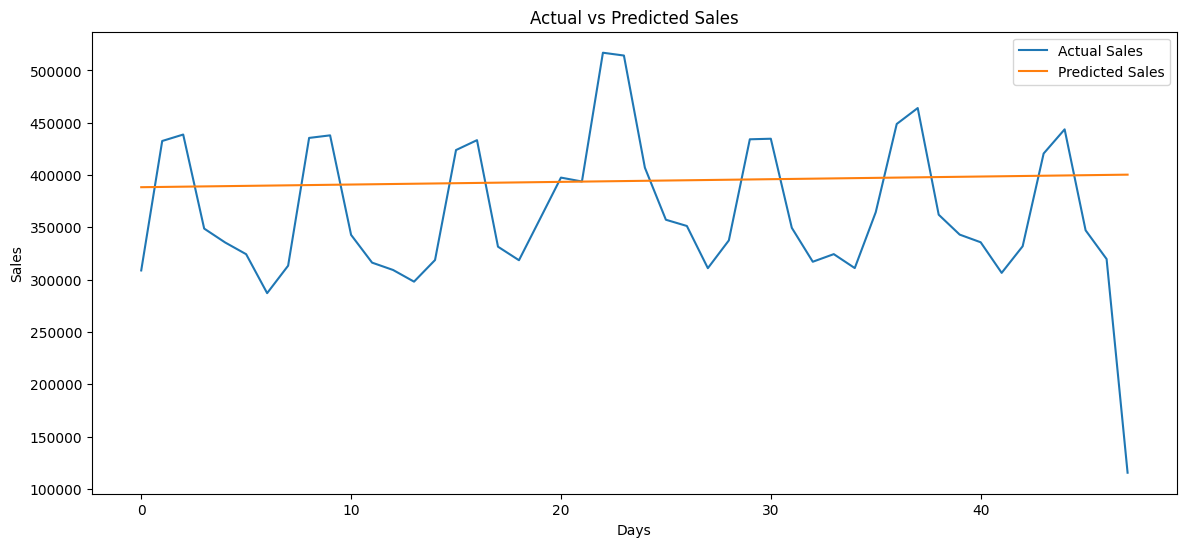

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


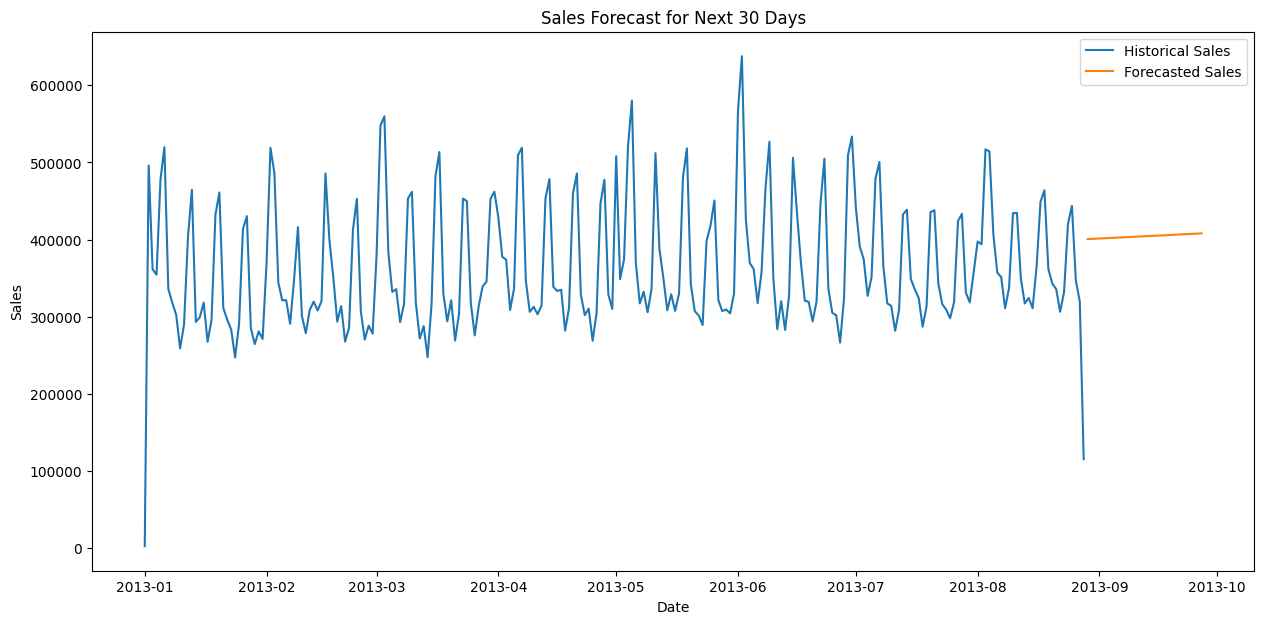

Forecast saved successfully


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('/content/train.csv')

df.head()
print(df.shape)
print(df.info())
print(df.isnull().sum())
df['date'] = pd.to_datetime(df['date'])
daily_sales = df.groupby('date')['sales'].sum().reset_index()

daily_sales.head()
plt.figure(figsize=(14,6))

plt.plot(daily_sales['date'],
         daily_sales['sales'])

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.savefig('daily_sales_trend.png', bbox_inches='tight')
plt.show()
daily_sales['year'] = daily_sales['date'].dt.year
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['day'] = daily_sales['date'].dt.day
daily_sales['dayofweek'] = daily_sales['date'].dt.dayofweek
daily_sales['time_index'] = np.arange(len(daily_sales))
X = daily_sales[['time_index']]
y = daily_sales['sales']
split_point = int(len(daily_sales)*0.8)

X_train = X[:split_point]
X_test = X[split_point:]

y_train = y[:split_point]
y_test = y[split_point:]
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print("MAE =", mae)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE =", rmse)
plt.figure(figsize=(14,6))

plt.plot(y_test.values,
         label='Actual Sales')

plt.plot(y_pred,
         label='Predicted Sales')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Days')
plt.ylabel('Sales')

plt.legend()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()
future_days = 30

future_index = np.arange(
    len(daily_sales),
    len(daily_sales)+future_days
).reshape(-1,1)

future_predictions = model.predict(future_index)
last_date = daily_sales['date'].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=future_days
)
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Sales': future_predictions
})

forecast_df.head()
plt.figure(figsize=(15,7))

plt.plot(
    daily_sales['date'],
    daily_sales['sales'],
    label='Historical Sales'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecasted_Sales'],
    label='Forecasted Sales'
)

plt.title('Sales Forecast for Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()
plt.savefig('sales_forecast.png', bbox_inches='tight')
plt.show()
forecast_df.to_csv(
    'sales_forecast.csv',
    index=False
)

print("Forecast saved successfully")



In [4]:
from google.colab import files

files.download('daily_sales_trend.png')
files.download('actual_vs_predicted.png')
files.download('sales_forecast.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import os

print(os.listdir())

['.config', 'sales_forecast.csv', 'daily_sales_trend.png', 'sales_forecast.png', 'train.csv', 'sample_data']


In [9]:
import os

print('sales_forecast.png' in os.listdir())

True


In [11]:
from google.colab import files

files.download('sales_forecast.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>